In [ ]:
!pip install statsmodels --upgrade

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import random

import tensorflow as tf

from tensorflow.keras.layers import Input, Lambda, Dense, Reshape, Flatten, \
    LSTM, Concatenate
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Model, load_model

from tensorflow.keras import metrics, losses
from tensorflow.keras import backend as K

from math import *

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.ar_model import AutoReg

tf.compat.v1.enable_eager_execution()

In [62]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [63]:
obs_data = np.load('/content/gdrive/My Drive/Colab Notebooks/Visobs.npy', allow_pickle=True)
combined_data = obs_data

In [64]:
data_list = combined_data.tolist()
print(len(data_list))
print(data_list)

27001
[8666.666666666666, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 4066.666666666667, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9333.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9666.0, 8666.333333333334, 9999.0, 9999.0, 9666.0, 9999.0, 9666.0, 8333.333333333334, 9999.0, 9666.0, 9333.0, 8666.666666666666, 8333.333333333334, 9000.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 9999.0, 8666.0, 6000.0, 5000.0, 4633.333333333333, 4000.0, 4366.666666666667, 4800.0, 4900.0, 6

In [69]:
print(len(data_list))

15430


In [66]:
count = 0

for i in range(len(data_list)):
  if data_list[i] < 9999.0 and data_list[i] > 5000 :
    count = count + 1

print(count)

2190


In [67]:
comp = data_list[1]
print(comp)

9999.0


In [68]:
for i in range(len(data_list)-1):
  if data_list[i] == comp:
      del data_list[i]

print(len(data_list))

IndexError: ignored

In [70]:
combined_data = np.array(data_list)
print(combined_data)
print(len(combined_data))
arr_length = len(combined_data)

[8666.66666667 9999.         9999.         ... 9999.         9999.
 9999.        ]
15430


In [71]:
temp_data = combined_data

combined_data = np.concatenate((combined_data,temp_data), axis = 0)
combined_data = np.concatenate((combined_data,temp_data), axis = 0)
combined_data = np.concatenate((combined_data,temp_data), axis = 0)
combined_data = np.concatenate((combined_data,temp_data), axis = 0)
print(combined_data)
print(len(combined_data))

[8666.66666667 9999.         9999.         ... 9999.         9999.
 9999.        ]
77150


In [72]:
combined_data = np.reshape(combined_data, (arr_length,5), order = 'F')
print(combined_data)
print(combined_data.shape)

[[8666.66666667 8666.66666667 8666.66666667 8666.66666667 8666.66666667]
 [9999.         9999.         9999.         9999.         9999.        ]
 [9999.         9999.         9999.         9999.         9999.        ]
 ...
 [9999.         9999.         9999.         9999.         9999.        ]
 [9999.         9999.         9999.         9999.         9999.        ]
 [9999.         9999.         9999.         9999.         9999.        ]]
(15430, 5)


13887


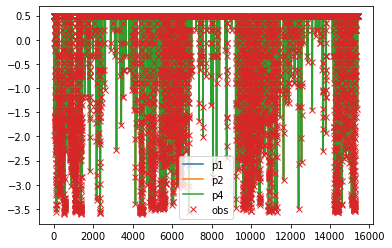

In [73]:
# Split into training data
TRAIN_SPLIT = np.int(0.9*len(combined_data))
print(TRAIN_SPLIT)

# Normalize the training data
data_mean = np.mean(combined_data[:TRAIN_SPLIT], axis=0)
data_std = np.std(combined_data[:TRAIN_SPLIT], axis=0)

dataset = (combined_data-data_mean)/data_std

# Plot part of data to make sure concatenation and normalization was successful
plt.plot(dataset[:,0])
plt.plot(dataset[:,1])
plt.plot(dataset[:,3])
plt.plot(dataset[:,4],'x')
plt.legend(['p1','p2','p4','obs'])

In [74]:
def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)

past_history = 48
future_target = 6
STEP = 1

x_train_multi, y_train_multi = multivariate_data(dataset, dataset[:, 4], 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_multi, y_val_multi = multivariate_data(dataset, dataset[:, 4],
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)

In [75]:
# Data shape
print ('Single window of past history : {}'.format(x_train_multi[0].shape))
print ('\n Target temperature to predict : {}'.format(y_train_multi[0].shape))

BATCH_SIZE = 16
BUFFER_SIZE = 1000000

train_data_multi = tf.data.Dataset.from_tensor_slices((x_train_multi, y_train_multi))
train_data_multi = train_data_multi.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_data_multi = tf.data.Dataset.from_tensor_slices((x_val_multi, y_val_multi))
val_data_multi = val_data_multi.batch(BATCH_SIZE).repeat()

Single window of past history : (48, 5)

 Target temperature to predict : (6,)


In [76]:
def create_time_steps(length):
  return list(range(-length, 0))

mean_error_ave = 0

In [77]:
def multi_step_plot(history, true_future, prediction):
  global mean_error_ave
  x = np.array(true_future).tolist()
  y = np.array(prediction).tolist()
  mean = 0
  for i in range(6) :
    mean = mean + ((x[i] - y[i])**2)
  mean_error = sqrt(mean/6)
  print("mean error is ", mean_error)
  mean_error_ave = mean_error_ave + (mean_error/6)
  plt.figure(figsize=(12, 6))
  num_in = create_time_steps(len(history))
  num_out = len(true_future)

  plt.plot(num_in, np.array(history[:, 1]), label='History')
  plt.plot(np.arange(num_out)/STEP, np.array(true_future), 'b',
           label='True Future')
  if prediction.any():
    plt.plot(np.arange(num_out)/STEP, np.array(prediction), 'r',
             label='Predicted Future')
  plt.legend(loc='upper left')
  plt.show()

In [78]:
#for x, y in train_data_multi.take(1):
  #multi_step_plot(x[0], y[0], np.array([0]))

multi_step_model = tf.keras.models.Sequential()
multi_step_model.add(tf.keras.layers.LSTM(32,
                                          return_sequences=True,
                                          input_shape=x_train_multi.shape[-2:]))
multi_step_model.add(tf.keras.layers.LSTM(16, activation='softsign'))
multi_step_model.add(tf.keras.layers.Dense(future_target))

multi_step_model.compile(optimizer=tf.keras.optimizers.RMSprop(clipvalue=1.0), loss='mae')

EVALUATION_INTERVAL = 200
EPOCHS = 10

multi_step_history = multi_step_model.fit(train_data_multi, epochs=EPOCHS,
                                          steps_per_epoch=EVALUATION_INTERVAL,
                                          validation_data=val_data_multi,
                                          validation_steps=50)

Epoch 1/10
200/200 [==============================] - 9s 44ms/step - loss: 0.4315 - val_loss: 0.6409
Epoch 2/10
200/200 [==============================] - 8s 41ms/step - loss: 0.3463 - val_loss: 0.6221
Epoch 3/10
200/200 [==============================] - 8s 42ms/step - loss: 0.2993 - val_loss: 0.5859
Epoch 4/10
200/200 [==============================] - 8s 40ms/step - loss: 0.2777 - val_loss: 0.5510
Epoch 5/10
200/200 [==============================] - 8s 40ms/step - loss: 0.2704 - val_loss: 0.5382
Epoch 6/10
200/200 [==============================] - 8s 40ms/step - loss: 0.2565 - val_loss: 0.5294
Epoch 7/10
200/200 [==============================] - 8s 40ms/step - loss: 0.2620 - val_loss: 0.5249
Epoch 8/10
200/200 [==============================] - 8s 41ms/step - loss: 0.2548 - val_loss: 0.5188
Epoch 9/10
200/200 [==============================] - 8s 40ms/step - loss: 0.2505 - val_loss: 0.5121
Epoch 10/10
200/200 [==============================] - 8s 40ms/step - loss: 0.2619 - val_lo

In [79]:
def plot_train_history(history, title):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(loss))

  plt.figure()

  plt.plot(epochs, loss, 'b', label='Training loss')
  plt.plot(epochs, val_loss, 'r', label='Validation loss')
  plt.title(title)
  plt.legend()

  plt.show()

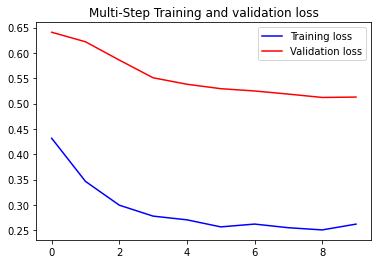

mean error is  14.56977056973276


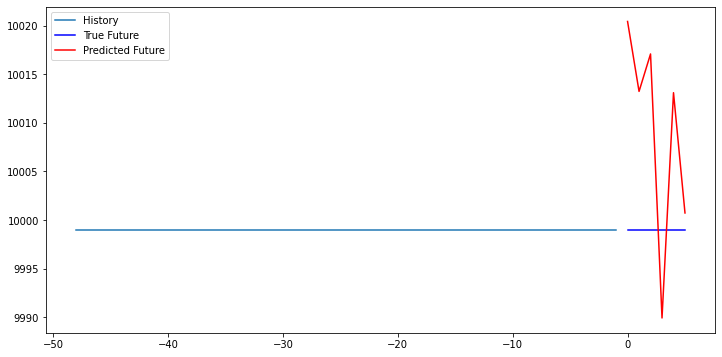

mean error is  14.56977056973276


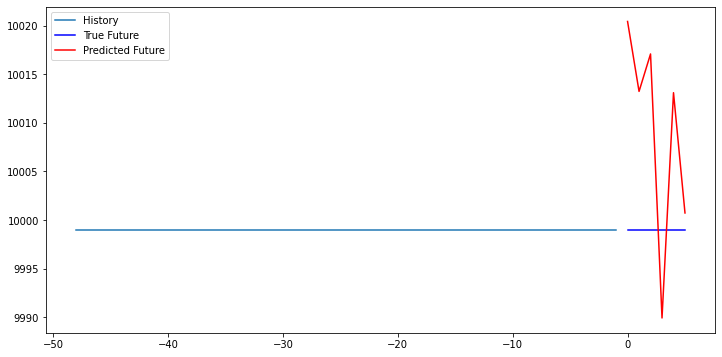

mean error is  14.56977056973276


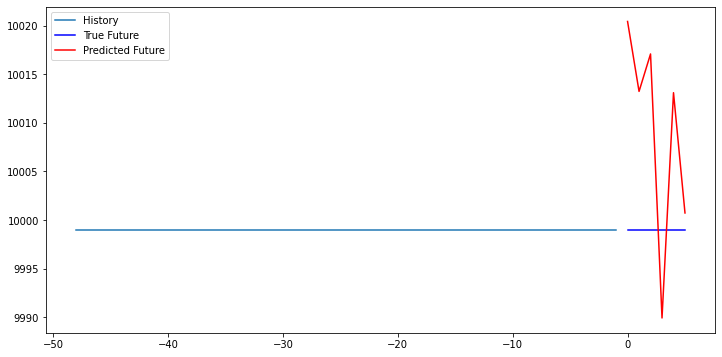

mean error is  14.56977056973276


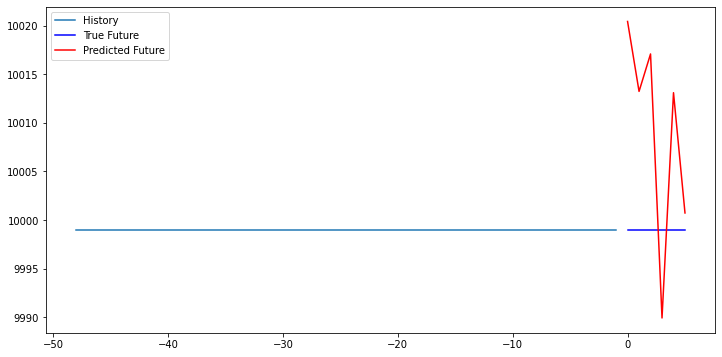

mean error is  14.56977056973276


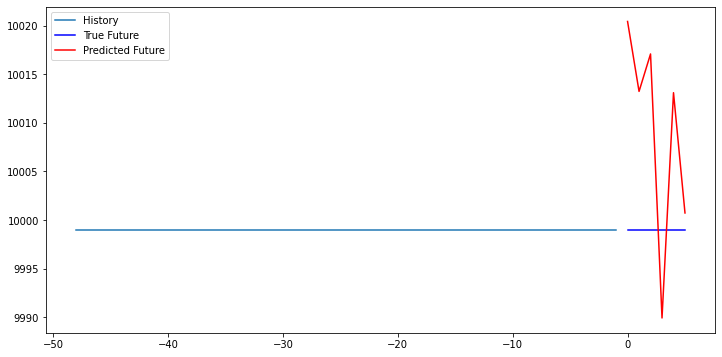

mean error is  14.56977056973276


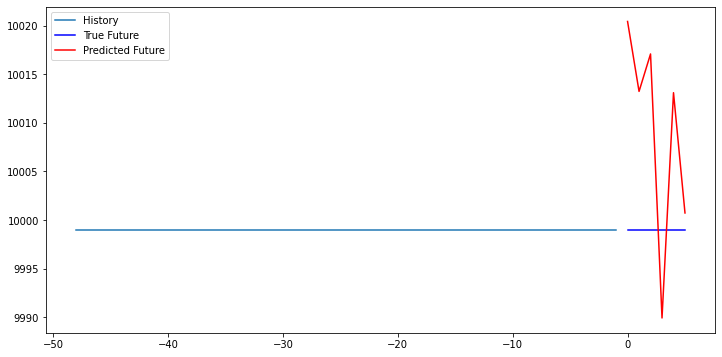

mean error average is  14.569770569732762


In [80]:
plot_train_history(multi_step_history, 'Multi-Step Training and validation loss')

for x, y in val_data_multi.take(6):
  multi_step_plot(data_mean[4]+data_std[4]*x[0], data_mean[4]+data_std[4]*y[0], 
                  data_mean[4]+data_std[4]*multi_step_model.predict(x)[0])

print("mean error average is ", mean_error_ave)

In [81]:
#TRYING OUT AR IMPLEMENTATION

X = combined_data

train, test = X[1:len(X)-7], X[len(X)-7:]
# train autoregression
window = 29
model = AutoReg(train, lags=29)
model_fit = model.fit()
coef = model_fit.params
# walk forward over time steps in test
history = train[len(train)-window:]
history = [history[i] for i in range(len(history))]
predictions = list()
for t in range(len(test)):
	length = len(history)
	lag = [history[i] for i in range(length-window,length)]
	yhat = coef[0]
	for d in range(window):
		yhat += coef[d+1] * lag[window-d-1]
	obs = test[t]
	predictions.append(yhat)
	history.append(obs)
	print('predicted=%f, expected=%f' % (yhat, obs))
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)
# plot
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,


TypeError: ignored